# Distribution et confrontation des notes (Livre vs Film)

Est-ce que les adaptations des livres au cinéma déçoivent le public ?

## Importations et Chargement des données

In [4]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Appel de la base de données SQLite
DB_PATH = os.path.join("..", "database", "cinema.db")

if not os.path.exists(DB_PATH):
    raise FileNotFoundError(f"❌ Base de données introuvable à l'emplacement : {os.path.abspath(DB_PATH)}")
    
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM adaptations", conn)
conn.close()

# Normalisation : Note du film sur 10 ramenée sur 5
df['movie_rating_norm'] = df['rating'] / 2

print(f"✅ Dataset chargé avec succès depuis le bon emplacement !")
print(f"📊 {df.shape[0]} lignes et {df.shape[1]} colonnes trouvées.")

✅ Dataset chargé avec succès depuis le bon emplacement !
📊 69 lignes et 20 colonnes trouvées.


## Statistiques descriptives globales

In [6]:
print("--- STATISTIQUES DESCRIPTIVES ---")
print(f"Note moyenne des Livres (sur 5) : {df['rating_average'].mean():.2f}/5")
print(f"Note moyenne des Films  (sur 5) : {df['movie_rating_norm'].mean():.2f}/5 (Originale : {df['rating'].mean():.2f}/10)")

# Calcul du vainqueur ligne par ligne
livre_meilleur = (df['rating_average'] > df['movie_rating_norm']).sum()
film_meilleur = (df['rating_average'] < df['movie_rating_norm']).sum()
egalite = (df['rating_average'] == df['movie_rating_norm']).sum()

print(f"\n --- LE DUEL MATRICIEL ---")
print(f"Le livre surpasse le film dans : {livre_meilleur} cas ({(livre_meilleur/len(df))*100:.1f}%)")
print(f"Le film surpasse le livre dans : {film_meilleur} cas ({(film_meilleur/len(df))*100:.1f}%)")
print(f"Égalité parfaite : {egalite} cas ({(egalite/len(df))*100:.1f}%)")

--- STATISTIQUES DESCRIPTIVES ---
Note moyenne des Livres (sur 5) : 4.07/5
Note moyenne des Films  (sur 5) : 3.52/5 (Originale : 7.03/10)

 --- LE DUEL MATRICIEL ---
Le livre surpasse le film dans : 65 cas (94.2%)
Le film surpasse le livre dans : 4 cas (5.8%)
Égalité parfaite : 0 cas (0.0%)


## Distribution des notes : œuvre originale vs son adaptation

C:\Users\estel\AppData\Local\Temp\ipykernel_2016\131837121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


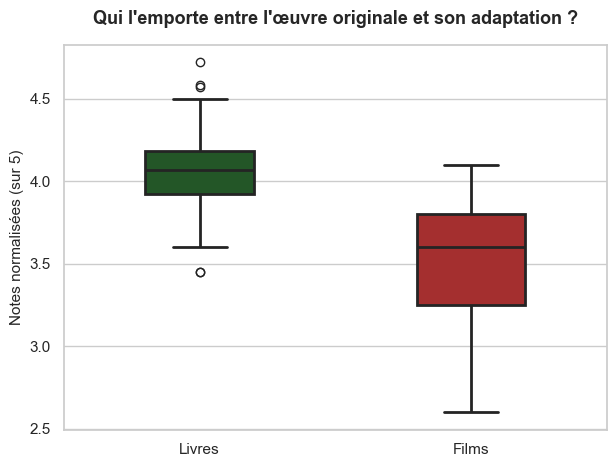

In [7]:
# Restructuration des données pour Seaborn (format long)
df_melt = df.melt(
    value_vars=['rating_average', 'movie_rating_norm'],
    var_name='Media', 
    value_name='Note'
)
df_melt['Media'] = df_melt['Media'].map({'rating_average': 'Livres', 'movie_rating_norm': 'Films'})

# Création du Boxplot
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_melt, 
    x='Media', 
    y='Note', 
    palette=['#1b5e20', '#b71c1c'], 
    width=0.4,
    linewidth=2
)

plt.title("Qui l'emporte entre l'œuvre originale et son adaptation ?", fontsize=13, pad=15, fontweight='bold')
plt.ylabel("Notes normalisées (sur 5)", fontsize=11)
plt.xlabel("", fontsize=11)

# Sauvegarde de la figure
os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/1_boxplot_distributions.png", bbox_inches='tight', dpi=150)
plt.show()

L'alignement des échelles de notation met en avant une tendance claire : l'œuvre littéraire originale surpasse presque systématiquement son adaptation cinématographique.

- Une supériorité globale des livres : La boîte à moustaches des livres (en vert) est nettement surélevée par rapport à celle des films (en rouge). La note médiane des œuvres originales frôle l'excellent score de 4,1/5, alors que celle des longs-métrages stagne aux alentours de 3,6/5.
- Le cinéma, plus clivant : La dispersion du boxplot des films est beaucoup plus large, s'étendant de $2,6$ à $4,1$. Cette forte volatilité prouve que l'adaptation en film est un exercice difficile : les flops critiques y sont fréquents et sévères. À l'inverse, la notation des livres est ultra-concentrée et stable autour de sa médiane, signe d'un public conquis. 
- Des exceptions confirmant la règle : On observe quelques outliers (points isolés) sous la boîte des livres, représentant de rares cas où l'œuvre papier a déçu, tandis que le plafond maximal des films ne parvient jamais à atteindre les sommets des meilleures notes littéraires ($> 4,5$).
 
En résumé : Le public se montre beaucoup plus sévère avec les films qu'avec les livres, confirmant l'adage populaire selon lequel "le livre était mieux".

## Corrélation entre la note du livre et celle du film ?

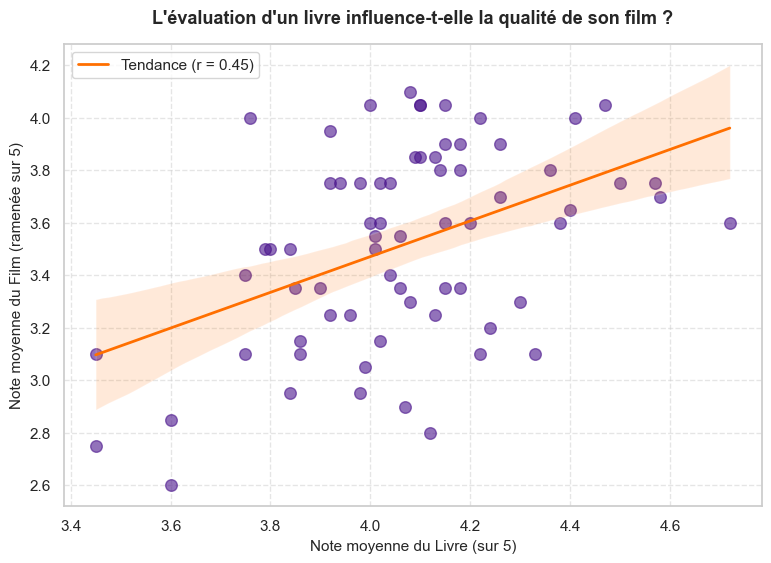

Indice de corrélation de Pearson : 0.45


In [9]:
# Calcul du coefficient de corrélation linéaire de Pearson
corr_pearson = df['rating_average'].corr(df['movie_rating_norm'])

# Création du scatter plot avec droite de tendance
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df, 
    x='rating_average', 
    y='movie_rating_norm', 
    color='#4a148c', 
    scatter_kws={'alpha': 0.6, 's': 70},
    line_kws={'color': '#ff6f00', 'lw': 2, 'label': f'Tendance (r = {corr_pearson:.2f})'}
)

plt.title("L'évaluation d'un livre influence-t-elle la qualité de son film ?", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Note moyenne du Livre (sur 5)", fontsize=11)
plt.ylabel("Note moyenne du Film (ramenée sur 5)", fontsize=11)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

# Sauvegarde
plt.savefig("../reports/figures/1_correlation_notes.png", bbox_inches='tight', dpi=150)
plt.show()

print(f"Indice de corrélation de Pearson : {corr_pearson:.2f}")

Ce nuage de points croisant les notes des œuvres originales et de leurs adaptations nous permet d'évaluer statistiquement si le succès critique d'un livre garantit la qualité de son film.

- Une corrélation positive modérée ($r = 0,45$) : L'indice de Pearson s'élève à $0,45$, matérialisé par la pente ascendante de la droite orange. En data science, cela indique une corrélation positive modérée. Il existe donc bien un lien réel : plus le livre est apprécié, plus le film a statistiquement de chances d'obtenir une bonne note. L'aura et la structure narrative d'un excellent livre capitalisent positivement sur l'adaptation.
- Un fort coefficient de dispersion (le "bruit" des données) : Bien que la tendance soit à la hausse, les points violets restent très dispersés autour de la droite de régression. Par exemple, pour un groupe important de livres concentrés autour de la note de $4,0/5$, les notes des films s'étalent de manière chaotique entre $2,9$ et $4,1$.L'indépendance de l'adaptation cinématographique : Cette forte dispersion prouve que la note du livre ne fait pas tout. Un excellent matériau littéraire d'origine ($> 4,5/5$) peut tout de même déboucher sur un film moyen (comme le point isolé en bas à droite à $3,6/5$). 
- Des facteurs propres à l'industrie du cinéma — le choix du réalisateur, le jeu des acteurs ou la réécriture du scénario — viennent fortement impacter le résultat final.
 
En résumé : Oui, un bon livre aide à faire un meilleur film, mais ce n'est absolument pas une garantie mathématique. L'adaptation reste une œuvre à part entière qui s'émancipe en grande partie de sa note d'origine.

## Focus sur les écarts majeurs

Concentrons nous sur les adaptations qui ont le plus "déçu" ou le plus "sublimé" l'oeuvre littéraire originale.

In [13]:
# Ajout d'une colonne d'écart (Note Livre - Note Film)
df['delta_rating'] = df['rating_average'] - df['movie_rating_norm']

# Les 3 films qui ont le plus "déçu" par rapport au livre
print("TOP 3 des pires adaptations (Le livre était bien meilleur) :")
top_deceptions = df.sort_values(by='delta_rating', ascending=False).head(3)
for _, row in top_deceptions.iterrows():
    print(f"   {row['title'].upper()} | Écart : +{row['delta_rating']:.2f} (Livre: {row['rating_average']:.2f} vs Film: {row['movie_rating_norm']:.2f})")

# Les 3 films qui ont surpassé le livre
print("\nTOP 3 des adaptations réussies (Le film a surpassé le livre) :")
top_reussites = df.sort_values(by='delta_rating', ascending=True).head(3)
for _, row in top_reussites.iterrows():
    print(f"   {row['title'].upper()} | Écart : {row['delta_rating']:.2f} (Livre: {row['rating_average']:.2f} vs Film: {row['movie_rating_norm']:.2f})")

TOP 3 des pires adaptations (Le livre était bien meilleur) :
   VAMPIRE ACADEMY | Écart : +1.32 (Livre: 4.12 vs Film: 2.80)
   HALF OF A YELLOW SUN | Écart : +1.23 (Livre: 4.33 vs Film: 3.10)
   THE THREE MUSKETEERS | Écart : +1.17 (Livre: 4.07 vs Film: 2.90)

TOP 3 des adaptations réussies (Le film a surpassé le livre) :
   CASINO ROYALE | Écart : -0.24 (Livre: 3.76 vs Film: 4.00)
   INTO THE WILD | Écart : -0.05 (Livre: 4.00 vs Film: 4.05)
   LIFE OF PI | Écart : -0.03 (Livre: 3.92 vs Film: 3.95)
